In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [141]:
path = r"/content/vendas.csv"
vendas = pd.read_csv(path, sep = ",", encoding="utf-8", decimal=".")
vendas

,data,loja,produto,quantidade,preco_unitario
0,2023-07-07,Loja B,Produto M,2.0,365.78
1,2023-12-05,Loja A,Produto Y,3.0,488.17
2,2023-02-21,Loja D,Produto Z,16.0,262.99
3,2023-09-19,Loja D,Produto X,9.0,168.25
4,2023-08-09,Loja D,Produto K,4.0,399.64
...,...,...,...,...,...
95,2023-11-05,Loja A,Produto X,6.0,379.73
96,2023-10-18,Loja A,Produto K,13.0,60.53
97,2023-10-25,Loja B,Produto Y,15.0,452.25
98,2023-07-11,Loja D,Produto M,3.0,257.57


In [142]:
vendas["data"] = pd.to_datetime(vendas["data"], errors="coerce")

In [143]:
vendas["faturamento"] = vendas["quantidade"] * vendas["preco_unitario"]
vendas

,data,loja,produto,quantidade,preco_unitario,faturamento
0,2023-07-07,Loja B,Produto M,2.0,365.78,731.56
1,2023-12-05,Loja A,Produto Y,3.0,488.17,1464.51
2,2023-02-21,Loja D,Produto Z,16.0,262.99,4207.84
3,2023-09-19,Loja D,Produto X,9.0,168.25,1514.25
4,2023-08-09,Loja D,Produto K,4.0,399.64,1598.56
...,...,...,...,...,...,...
95,2023-11-05,Loja A,Produto X,6.0,379.73,2278.38
96,2023-10-18,Loja A,Produto K,13.0,60.53,786.89
97,2023-10-25,Loja B,Produto Y,15.0,452.25,6783.75
98,2023-07-11,Loja D,Produto M,3.0,257.57,772.71


In [144]:
vendas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   data            100 non-null    datetime64[ns]
 1   loja            100 non-null    object        
 2   produto         100 non-null    object        
 3   quantidade      99 non-null     float64       
 4   preco_unitario  98 non-null     float64       
 5   faturamento     97 non-null     float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 4.8+ KB


In [145]:
vendas.isnull()

,data,loja,produto,quantidade,preco_unitario,faturamento
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
95,False,False,False,False,False,False
96,False,False,False,False,False,False
97,False,False,False,False,False,False
98,False,False,False,False,False,False


In [146]:

vendas.describe().round(2)

,data,quantidade,preco_unitario,faturamento
count,100,99.00,98.00,97.00
mean,2023-07-05 08:52:48,9.32,255.17,2414.69
min,2023-01-04 00:00:00,1.00,17.05,48.44
25%,2023-03-24 06:00:00,4.00,135.14,695.28
50%,2023-07-14 00:00:00,9.00,260.28,1598.56
75%,2023-10-05 00:00:00,14.50,377.90,3512.46
max,2023-12-31 00:00:00,19.00,495.35,7734.24
std,NaN,5.84,146.45,2195.77


In [147]:
vendas[["quantidade", "preco_unitario"]] = vendas[["quantidade", "preco_unitario"]].fillna(vendas[["quantidade", "preco_unitario"]].mean())


In [148]:
faturamentoPorLoja = vendas.groupby("loja")["faturamento"].sum().round(2)

In [149]:
faturamentoPorLoja

,faturamento
loja,
Loja A,53878.61
Loja B,34534.27
Loja C,63814.93
Loja D,48044.09
Loja E,33952.77


In [150]:
numVendas = vendas.shape[0]
ticketMedio = faturamentoPorLoja / numVendas

In [151]:
ticketMedio

,faturamento
loja,
Loja A,538.7861
Loja B,345.3427
Loja C,638.1493
Loja D,480.4409
Loja E,339.5277


In [152]:
cincoMaisVendidos = vendas.sort_values("quantidade", ascending=False).iloc[0:5]

In [153]:
cincoMaisVendidos

,data,loja,produto,quantidade,preco_unitario,faturamento
22,2023-08-05,Loja B,Produto M,19.0,281.63,5350.97
30,2023-11-27,Loja E,Produto Y,19.0,32.54,618.26
17,2023-11-16,Loja C,Produto M,19.0,360.15,6842.85
77,2023-12-05,Loja A,Produto X,19.0,351.40,6676.60
81,2023-06-08,Loja D,Produto W,19.0,403.71,7670.49


In [154]:
vendas["mes"] = vendas["data"].dt.month

faturamentoMes = vendas.groupby("mes")["faturamento"].sum()

maiorFat = faturamentoMes.idxmax()
menorFat = faturamentoMes.idxmin()

In [155]:
print(f"0{maiorFat}/23 - {faturamentoMes.max()}")
print(f"0{menorFat}/23 - {faturamentoMes.min()}")

08/23 - 34106.8
04/23 - 5100.2


In [156]:
vendas["faturamentoPorLoja"] = faturamentoPorLoja

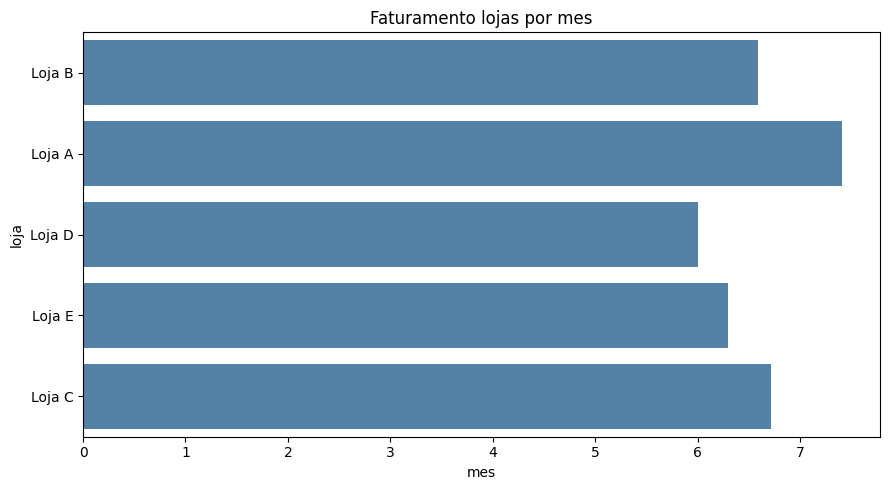

In [167]:
fig, ax = plt.subplots(figsize=(9, 5))
ordem = vendas.sort_values("faturamentoPorLoja", ascending=False)
sns.barplot(data=ordem, y="loja", x="mes", ax=ax, color="steelblue", errorbar=None)
ax.set_title("Faturamento lojas por mes")
ax.set_xlabel("mes")
ax.set_ylabel("loja")
plt.tight_layout()
plt.savefig('graficos/faturamento_por_loja.png', dpi=300, bbox_inches='tight')
plt.show()

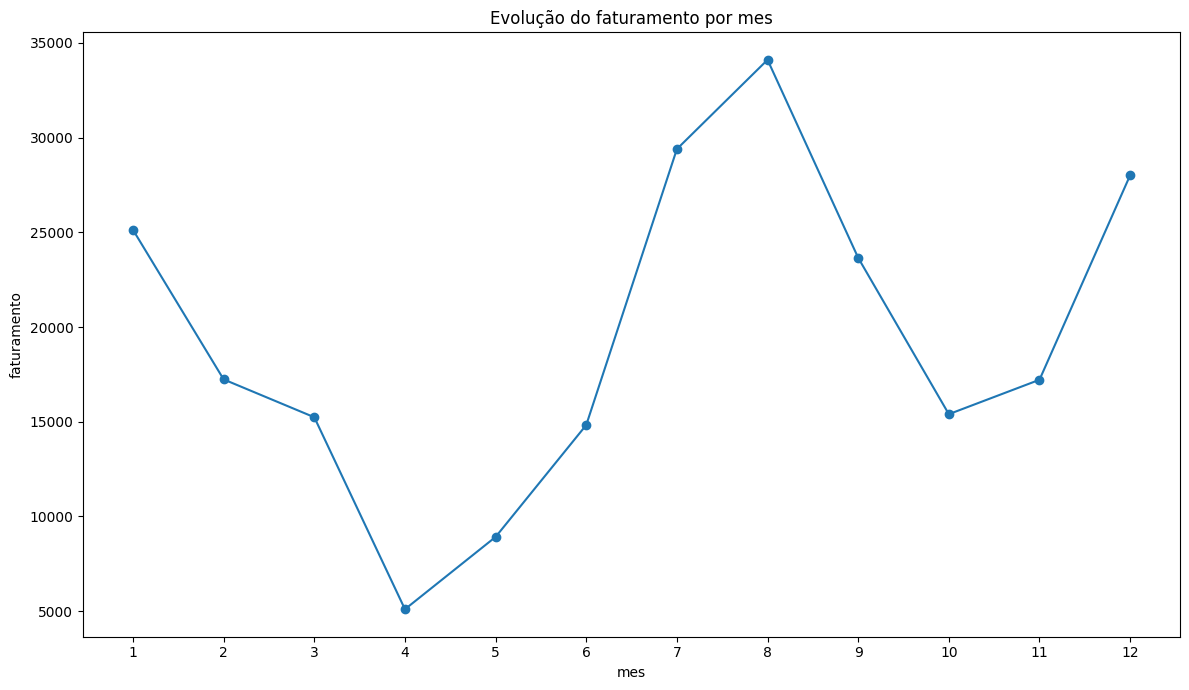

In [168]:
fig, ax = plt.subplots(figsize=(12, 7))

ax.plot(faturamentoMes.index, faturamentoMes.values, marker="o", linewidth=1.5)

ax.set_title("Evolução do faturamento por mes")
ax.set_xlabel("mes")
ax.set_ylabel("faturamento")
ax.set_xticks(range(1, 13))
plt.savefig('graficos/evolucao_faturamento_por_mes.png', dpi=300, bbox_inches='tight')
fig.tight_layout()
plt.show()


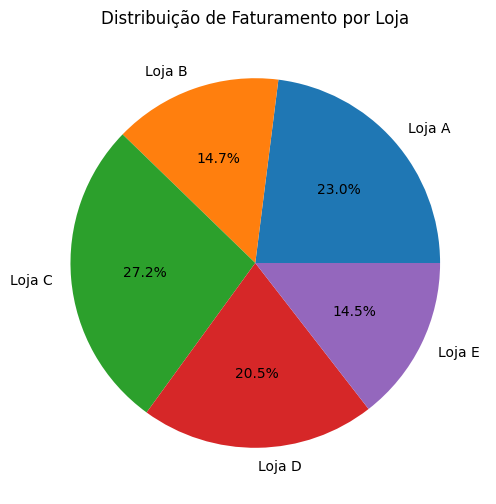

In [169]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(faturamentoPorLoja, labels=faturamentoPorLoja.index, autopct="%1.1f%%")
ax.set_title("Distribuição de Faturamento por Loja")
plt.savefig('graficos/distribuicao_faturamento_por_loja.png', dpi=300, bbox_inches='tight')
plt.show()

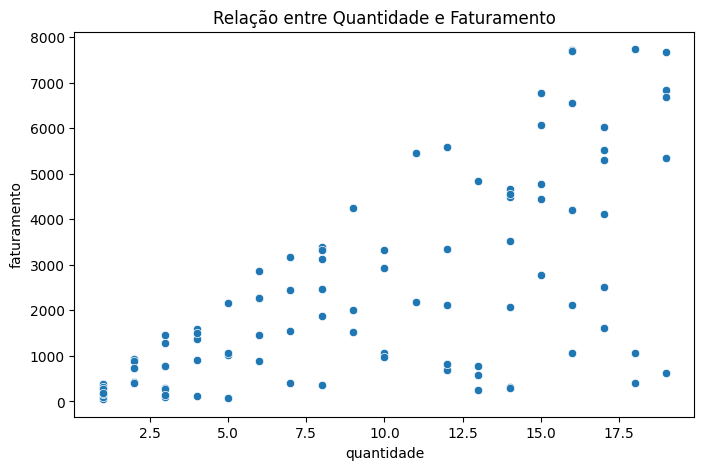

In [170]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=vendas, x="quantidade", y="faturamento", ax=ax)
ax.set_title("Relação entre Quantidade e Faturamento")
plt.savefig('graficos/relacao_quantidade_e_faturamento.png', dpi=300, bbox_inches='tight')
plt.show()

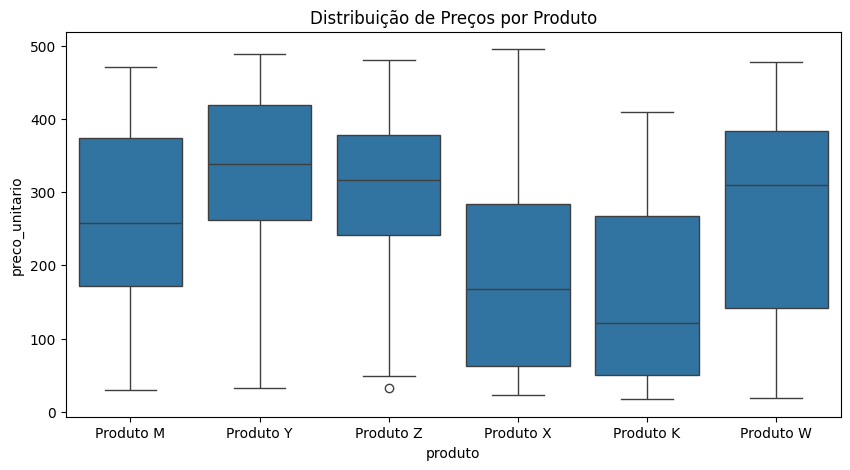

In [171]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=vendas, x="produto", y="preco_unitario", ax=ax)
ax.set_title("Distribuição de Preços por Produto")
plt.savefig('graficos/distribuicao_precos_por_produto.png', dpi=300, bbox_inches='tight')
plt.show()


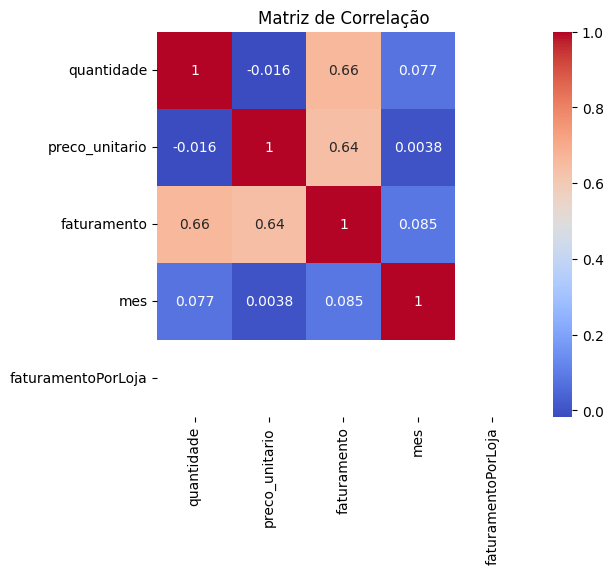

In [172]:
fig, ax = plt.subplots(figsize=(6, 5))
matriz_corr = vendas.corr(numeric_only=True)
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", ax=ax)
ax.set_title("Matriz de Correlação")
plt.savefig('graficos/matriz_correlacao.png', dpi=300, bbox_inches='tight')
plt.show()

In [173]:
vendas.to_csv("resumo_analitico.csv")